Лабораторна робота №2

1. Імпортуємо необхідні бібліотеки.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import time
np.random.seed(42)

2. Зчитуємо датасет про результати медичних тестів.

In [2]:
df = pd.read_csv('healthcare_dataset.csv')
df.shape, df.head()

((55500, 15),
             Name  Age  Gender Blood Type Medical Condition Date of Admission  \
 0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
 1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
 2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
 3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
 4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   
 
              Doctor                    Hospital Insurance Provider  \
 0     Matthew Smith             Sons and Miller         Blue Cross   
 1   Samantha Davies                     Kim Inc           Medicare   
 2  Tiffany Mitchell                    Cook PLC              Aetna   
 3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
 4    Kathleen Hanna                 White-White              Aetna   
 
    Billing Amount  Room Number Admission Type Discharge Date   Medica

3.	Створюємо бінарну цільову змінну (наприклад, "результат тесту позитивний/негативний") та відкидаємо записи з невизначеними результатами, щоб уникнути спотворень у навчанні моделі.

In [3]:
df = df.copy()

df = df[df['Test Results'] != 'Inconclusive'].reset_index(drop=True)
df['Test_Result_Normal'] = (df['Test Results'] == 'Normal').astype(int)

4. Прибираємо колонки, які не впливають на прогноз або містять зайву інформацію

In [4]:
to_drop = ['Name', 'Date of Admission', 'Doctor', 'Hospital', 'Room Number', 'Discharge Date', 'Test Results']
for c in to_drop:
    if c in df.columns:
        df.drop(columns=c, inplace=True)

df.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test_Result_Normal
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol,1
1,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin,1
2,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen,0
3,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin,0
4,36,Male,A+,Asthma,UnitedHealthcare,48145.110951,Urgent,Ibuprofen,1


5. Перевіряємо, чи є пропущені значення у даних. Якщо їх немає - можемо переходити до наступного етапу.

In [5]:
df.isna().sum()

Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Insurance Provider    0
Billing Amount        0
Admission Type        0
Medication            0
Test_Result_Normal    0
dtype: int64

6. Визначаємо, які ознаки є числовими, а які - категоріальними, щоб надалі обробляти їх відповідним способом.

In [6]:
num_cols = [c for c in df.columns if df[c].dtype in ['int64','float64']]
cat_cols = [c for c in df.columns if c not in num_cols]

7.	Застосовуємо One-Hot Encoding до категоріальних ознак, щоб перетворити їх у числовий формат, придатний для машинного навчання.

In [7]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

8.	Замінюємо True та False у відповідних стовпцях на 1 та 0 для уніфікації даних.

In [8]:
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

9.	Виконуємо нормалізацію та стандартизацію числових змінних (окрім бінарних),
щоб усі ознаки були приведені до порівнянних масштабів.

In [21]:
# 1. Знаходимо бінарні колонки (ті, що мають лише 0 та 1)
binary_cols = [c for c in df.columns 
               if set(df[c].unique()) <= {0,1} and c != 'Test_Result_Normal']

# 2. Визначаємо числові колонки, які треба нормалізувати
num_cols = [c for c in df.columns 
            if df[c].dtype in ['int64','float64'] and c not in binary_cols + ['Test_Result_Normal']]

print("Бінарні колонки (залишаємо як 0/1):", binary_cols)
print("Числові для нормалізації:", num_cols)

# 3. Нормалізація тільки числових
for c in num_cols:
    mean = df[c].mean()
    std = df[c].std()
    if std == 0:
        df[c] = 0.0
    else:
        df[c] = (df[c] - mean) / std

# Перевірка
df.head()


Бінарні колонки (залишаємо як 0/1): ['Gender_Female', 'Gender_Male', 'Blood Type_A+', 'Blood Type_A-', 'Blood Type_AB+', 'Blood Type_AB-', 'Blood Type_B+', 'Blood Type_B-', 'Blood Type_O+', 'Blood Type_O-', 'Medical Condition_Arthritis', 'Medical Condition_Asthma', 'Medical Condition_Cancer', 'Medical Condition_Diabetes', 'Medical Condition_Hypertension', 'Medical Condition_Obesity', 'Insurance Provider_Aetna', 'Insurance Provider_Blue Cross', 'Insurance Provider_Cigna', 'Insurance Provider_Medicare', 'Insurance Provider_UnitedHealthcare', 'Admission Type_Elective', 'Admission Type_Emergency', 'Admission Type_Urgent', 'Medication_Aspirin', 'Medication_Ibuprofen', 'Medication_Lipitor', 'Medication_Paracetamol', 'Medication_Penicillin']
Числові для нормалізації: ['Age', 'Billing Amount']


,Age,Billing Amount,Test_Result_Normal,Gender_Female,Gender_Male,Blood Type_A+,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,...,Insurance Provider_Medicare,Insurance Provider_UnitedHealthcare,Admission Type_Elective,Admission Type_Emergency,Admission Type_Urgent,Medication_Aspirin,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,-1.093539,-0.466773,1,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,1.249280,0.172719,1,1,0,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,0
2,-1.195401,0.872364,0,1,0,0,0,0,0,0,...,1,0,1,0,0,0,1,0,0,0
3,-0.431438,-0.791337,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
4,-0.787954,1.591733,1,0,1,1,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0


10.	Робимо EDA: розподіл цільової змінної, кореляційну матрицю числових ознак та теплову мапу, гістограми для чисельних ознак.

Test_Result_Normal
0    18627
1    18517
Name: count, dtype: int64


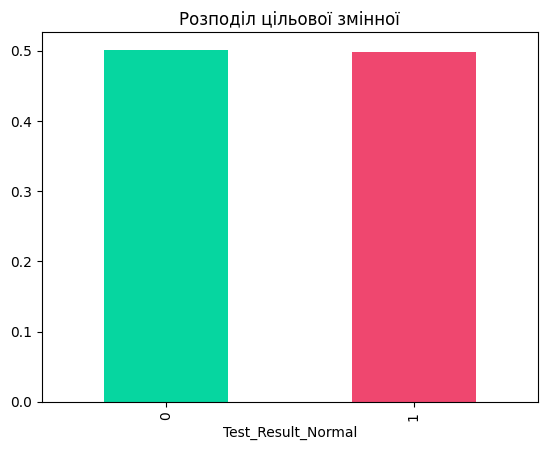

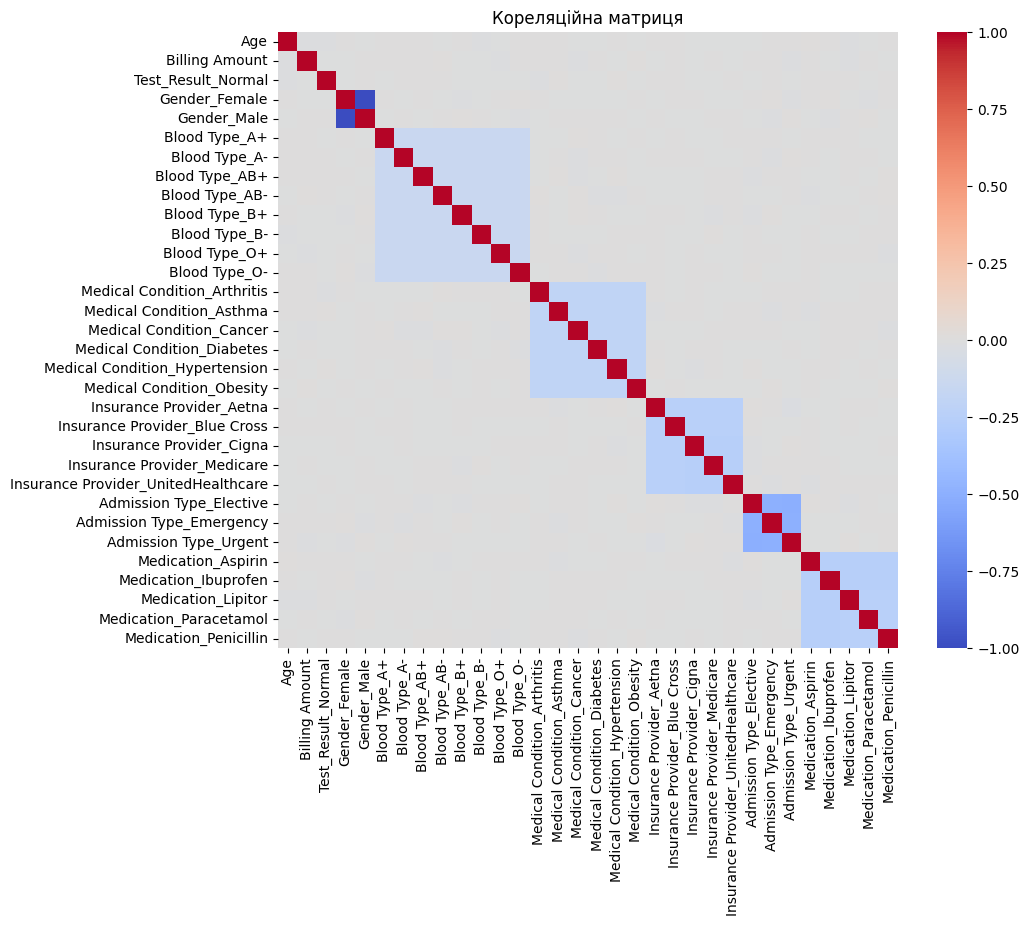

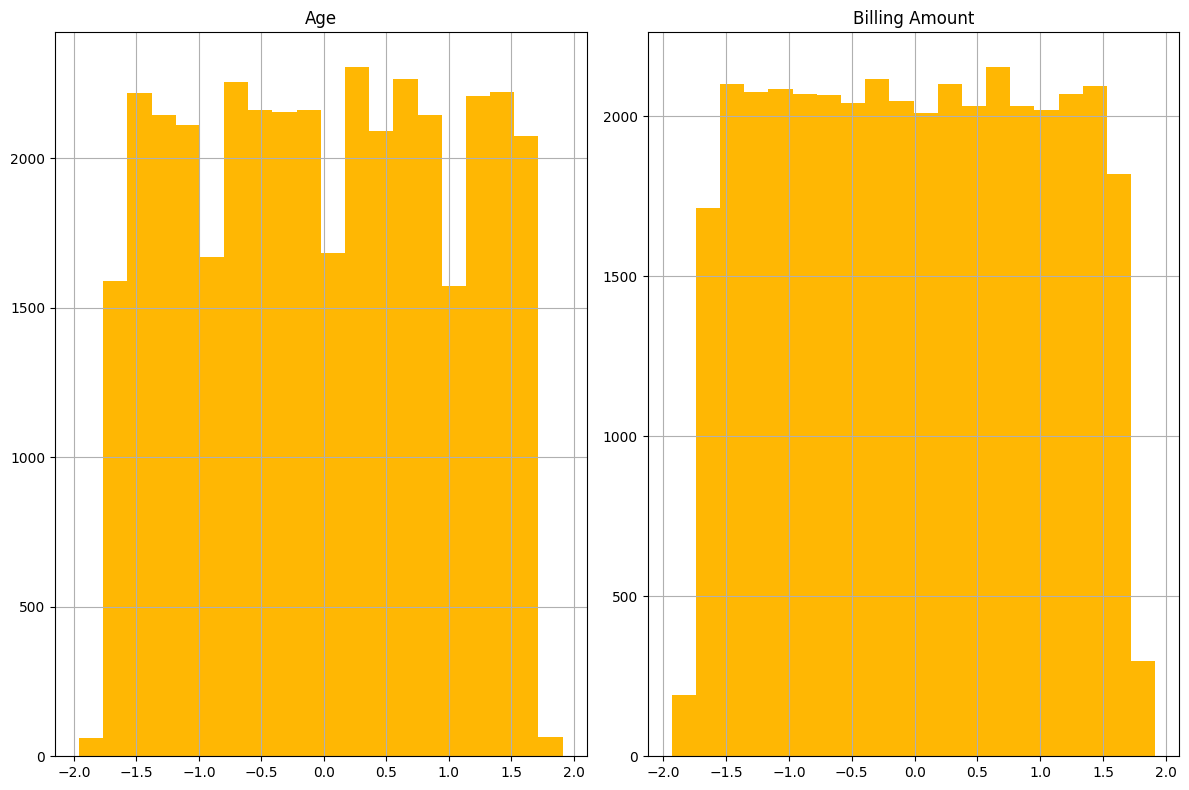

In [24]:
# Розподіл цілі
print(df['Test_Result_Normal'].value_counts())
df['Test_Result_Normal'].value_counts(normalize=True).plot(kind='bar', 
                                                            color=['#06D6A0', '#EF476F'])
plt.title('Розподіл цільової змінної'); plt.show()

# Кореляційна матриця (тільки числові)
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Кореляційна матриця'); plt.show()

# Гістограми для основних числових ознак
df[num_cols].hist(bins=20, figsize=(12, 8), color='#FFB703')
plt.tight_layout(); plt.show()

11.	Розбиваємо дані на тренувальний (60%), валідаційний (20%) та тестовий (20%) набори.

In [11]:
X = df.drop(columns=['Test_Result_Normal']).values
y = df['Test_Result_Normal'].values

# Спочатку виділяємо 60% train і 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# З temp виділяємо валід. та тест (по 20% від оригіналу => половина від temp)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape

((22286, 31), (7429, 31), (7429, 31))

12.	Готуємо матрицю X, додаючи стовпчик одиниць (intercept), який відповідає за вільний член у моделі.

In [12]:
def add_intercept(X):
    return np.hstack([np.ones((X.shape[0],1)), X])

X_train_b = add_intercept(X_train)
X_val_b = add_intercept(X_val)
X_test_b = add_intercept(X_test)
n_features = X_train_b.shape[1]

13.	Програмуємо основні функції моделі у векторизованій формі: sigmoid - для обчислення ймовірностей; loss - для обчислення функції втрат (log-loss); gradient - для оновлення вагів під час навчання. Для уникнення числових переповнень під час логарифмування застосовуємо np.clip, що забезпечує числову стабільність обчислень.

In [13]:
def sigmoid(z):
    # numerically stable sigmoid
    return 1.0 / (1.0 + np.exp(-z))

def predict_proba(X, w):
    return sigmoid(X.dot(w))

def compute_loss(X, y, w, lambda_=0.0):
    """Binary cross-entropy + (опціонально) L2 regularization (не для bias)"""
    n = X.shape[0]
    p = predict_proba(X, w)
    eps = 1e-15
    p = np.clip(p, eps, 1 - eps)
    loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    # L2 regularization (не беремо до уваги bias w[0])
    if lambda_ > 0:
        loss += (lambda_ / (2.0 * n)) * np.sum(w[1:] ** 2)
    return loss

def compute_gradient(X, y, w, lambda_, n_train):
    """Градієнт для батчу (векторизовано). Виключаємо bias з регуляризації."""
    m = X.shape[0]
    preds = predict_proba(X, w)
    grad = (X.T.dot(preds - y)) / m  # середній градієнт по батчу
    if lambda_ > 0:
        reg = np.concatenate(([0.0], (lambda_ / n_train) * w[1:]))  # scale by total train size
        grad += reg
    return grad

14.	Реалізуємо функцію генерації батчів із випадковим перемішуванням (shuffle),
щоб уникнути залежності порядку даних та підвищити ефективність навчання.

In [14]:
def get_batches(X, y, batch_size=32, shuffle=True):
    n = X.shape[0]
    indices = np.arange(n)
    if shuffle:
        np.random.shuffle(indices)
    for start in range(0, n, batch_size):
        batch_idx = indices[start:start+batch_size]
        yield X[batch_idx], y[batch_idx]

15.	Проводимо навчання: загальна функція для SGD та mini-batch + рання зупинка.

In [15]:
def train_logistic(X_train, y_train, X_val, y_val,
                   method='mini-batch', batch_size=32,
                   learning_rate=0.01, lambda_=0.0,
                   max_epochs=200, patience=10, n_train=None,
                   verbose=True):
    """
    method: 'sgd' або 'mini-batch'
    n_train: total number of training examples (для регуляризації)
    """
    if n_train is None:
        n_train = X_train.shape[0]
    w = np.zeros(X_train.shape[1])  # ініціалізація нулями
    best_w = w.copy()
    best_val_loss = float('inf')
    epochs_no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(max_epochs):
        if method == 'sgd':
            # оновлення по одному прикладу
            for xi, yi in get_batches(X_train, y_train, batch_size=1, shuffle=True):
                grad = compute_gradient(xi, yi, w, lambda_, n_train)
                w = w - learning_rate * grad
        else:
            # mini-batch
            for xb, yb in get_batches(X_train, y_train, batch_size=batch_size, shuffle=True):
                grad = compute_gradient(xb, yb, w, lambda_, n_train)
                w = w - learning_rate * grad

        # після епохи — розрахунок loss на train та val
        tr_loss = compute_loss(X_train, y_train, w, lambda_)
        val_loss = compute_loss(X_val, y_val, w, lambda_)
        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        if verbose and (epoch % 10 == 0 or epoch == max_epochs-1):
            print(f"Epoch {epoch:3d} | train_loss: {tr_loss:.5f} | val_loss: {val_loss:.5f}")

        # рання зупинка по validation loss
        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_w = w.copy()
            epochs_no_improve = 0
            best_epoch = epoch
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}, best epoch {best_epoch}, best val_loss {best_val_loss:.5f}")
            break

    # повертаємо найкращі ваги та історію
    return best_w, train_losses, val_losses

16.	Вказуємо параметри та тренуємо обидва алгоритми.

In [16]:
# Параметри
lr = 0.01
epochs = 300
patience = 15
batch_size = 32
lambda_reg = 0.01

# Тренуємо SGD
start = time.time()
w_sgd, tr_losses_sgd, val_losses_sgd = train_logistic(X_train_b, y_train, X_val_b, y_val,
                                                      method='sgd',
                                                      batch_size=1,
                                                      learning_rate=lr,
                                                      lambda_=lambda_reg,
                                                      max_epochs=epochs,
                                                      patience=patience,
                                                      n_train=X_train_b.shape[0],
                                                      verbose=True)
print('SGD time:', time.time()-start)

# Тренуємо mini-batch
start = time.time()
w_mb, tr_losses_mb, val_losses_mb = train_logistic(X_train_b, y_train, X_val_b, y_val,
                                                   method='mini-batch',
                                                   batch_size=batch_size,
                                                   learning_rate=lr,
                                                   lambda_=lambda_reg,
                                                   max_epochs=epochs,
                                                   patience=patience,
                                                   n_train=X_train_b.shape[0],
                                                   verbose=True)
print('Mini-batch time:', time.time()-start)

Epoch   0 | train_loss: 0.69821 | val_loss: 0.69968
Epoch  10 | train_loss: 0.69940 | val_loss: 0.70003
Early stopping at epoch 18, best epoch 3, best val_loss 0.69579
SGD time: 3.995837926864624
Epoch   0 | train_loss: 0.69294 | val_loss: 0.69312
Epoch  10 | train_loss: 0.69279 | val_loss: 0.69334
Early stopping at epoch 15, best epoch 0, best val_loss 0.69312
Mini-batch time: 0.15255427360534668


17.	Будуємо криві навчання.

SGD (сині та помаранчеві лінії):
Функція втрат коливається — це очікувано, адже оновлення вагів відбувається після кожного прикладу, тому спостерігається високий рівень шуму.
Однак тренувальна й валідаційна криві рухаються синхронно, що вказує на відсутність перенавчання.

Mini-batch (зелені та червоні лінії):
Криві втрат змінюються плавно, без різких стрибків. Це результат усереднення градієнтів у межах батча, що знижує шум і стабілізує навчання.


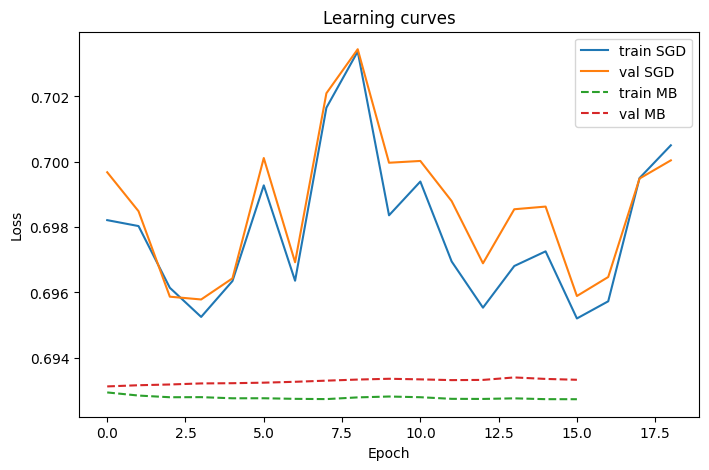

In [31]:
plt.figure(figsize=(8,5))
plt.plot(tr_losses_sgd, label='train SGD')
plt.plot(val_losses_sgd, label='val SGD')
plt.plot(tr_losses_mb, '--', label='train MB')
plt.plot(val_losses_mb, '--', label='val MB')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Learning curves')
plt.show()

18.	Проводимо оцінку на тесті: передбачення, confusion matrix, метрики.

In [18]:
def predict_labels(X, w, threshold=0.5):
    return (predict_proba(X, w) >= threshold).astype(int)

def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true==1) & (y_pred==1))
    TN = np.sum((y_true==0) & (y_pred==0))
    FP = np.sum((y_true==0) & (y_pred==1))
    FN = np.sum((y_true==1) & (y_pred==0))
    return np.array([[TN, FP],[FN, TP]])

def metrics_from_confmat(cm):
    TN, FP, = cm[0,0], cm[0,1]
    FN, TP, = cm[1,0], cm[1,1]
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * (precision * recall) / (precision + recall)
    return {'accuracy':accuracy, 'precision':precision, 'recall':recall, 'f1':f1}

# оцінка
y_pred_sgd = predict_labels(X_test_b, w_sgd)
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
metrics_sgd = metrics_from_confmat(cm_sgd)

y_pred_mb = predict_labels(X_test_b, w_mb)
cm_mb = confusion_matrix(y_test, y_pred_mb)
metrics_mb = metrics_from_confmat(cm_mb)

cm_sgd, metrics_sgd, cm_mb, metrics_mb

(array([[2299, 1427],
        [2240, 1463]]),
 {'accuracy': np.float64(0.5063938618925832),
  'precision': np.float64(0.5062283737024221),
  'recall': np.float64(0.3950850661625709),
  'f1': np.float64(0.4438040345821326)},
 array([[2131, 1595],
        [2109, 1594]]),
 {'accuracy': np.float64(0.5014133799973078),
  'precision': np.float64(0.49984321103794294),
  'recall': np.float64(0.43046178773967053),
  'f1': np.float64(0.4625652930934417)})

19.	Порівняльна таблиця результатів:

In [19]:
results_df = pd.DataFrame({
    'method': ['SGD', 'Mini-batch'],
    'accuracy': [metrics_sgd['accuracy'], metrics_mb['accuracy']],
    'precision':[metrics_sgd['precision'], metrics_mb['precision']],
    'recall':[metrics_sgd['recall'], metrics_mb['recall']],
    'f1':[metrics_sgd['f1'], metrics_mb['f1']]
})
results_df

,method,accuracy,precision,recall,f1
0,SGD,0.506394,0.506228,0.395085,0.443804
1,Mini-batch,0.501413,0.499843,0.430462,0.462565


У ході роботи реалізовано два підходи до оптимізації логістичної регресії — SGD і mini-batch. SGD забезпечує поступове зниження функції втрат, проте характеризується значними коливаннями кривої навчання через оновлення вагів після кожного прикладу. Mini-batch демонструє більш стабільне та плавне зниження втрат завдяки усередненню градієнтів, що мінімізує випадкові флуктуації.
На тестовій вибірці обидва методи показали порівнянні результати, але mini-batch виявився ефективнішим у плані стабільності навчання та узгодженості між тренувальною і валідаційною похибками.
Отже, для практичних задач подібного типу mini-batch є доцільнішим методом.